# No-Metasurface Baseline Notebook

Experimental variant of [`training_ms_notebook.ipynb`](./training_ms_notebook.ipynb) with the metasurface **removed**.

## Idea

In the original pipeline the defect field propagates from the rail to the metasurface plane (that propagation is precomputed in the dataset), then passes through trainable phase layers plus further free-space propagation before reaching 3 detectors. Here the pipeline **stops at the metasurface plane**: a dense array of detectors sits where the metasurface used to be and reads the arriving intensity directly. No optical elements exist, and the diffraction propagation from the rail is unchanged.

## Variants

1. **A - Fixed baseline**: fixed detector array, no training at all. The separation loss/metrics are used purely as measurements.
2. **B - Digital readout**: the detector powers are mixed by a trainable linear layer (electronic post-processing), trained with the same separation loss.
3. **C - Trainable detector positions**: the detector centers themselves are optimized (via differentiable soft windows) with the same loss - physically, choosing where to place the sensors.

All variants share the dataset, splits, margin (40%), and loss definitions of the original notebook, so results are directly comparable with the trained-metasurface ONN.

In [ ]:
# Core utilities for checkpoint copying.
from copy import deepcopy
from pathlib import Path

# Plotting and numerical tools.
import matplotlib.pyplot as plt
import numpy as np
import plot_setting

# PyTorch modules used for detector readout and optimization.
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

# Prefer CUDA NVIDIA GPU on WindowsOS when available; otherwise fall back to CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")

## 1. Physical Setup, Detector Array, And Dataset Configuration

Same physical constants and dataset as the original notebook. The new part is the **dense detector array**: `N_det` windows tiling the full aperture at the (former) metasurface plane.

In [ ]:
# Unit conversion and physical parameters (identical to the original notebook).
mm = 1e3
wvl = 12 * mm
k0 = 2 * np.pi / wvl
W = 20 * wvl

y_ms = 250 * mm
dx_ms = wvl / 10

# Sample points along the (former) metasurface aperture.
v_ms_x = torch.arange(-W / 2, W / 2, dx_ms) + dx_ms / 2
v_ms_y = torch.zeros_like(v_ms_x) + y_ms
v_ms = torch.stack([v_ms_x, v_ms_y], dim=1)
resol = len(v_ms_x)

# Dense detector array tiling the aperture at the metasurface plane.
N_det = 15
det_width = W / N_det
det_centers = torch.arange(N_det) * det_width - W / 2 + det_width / 2

# Training settings for the trainable variants (B and C).
N_epoch_no_ms = 300
batch_size = 1000

# Large input datasets live in the external RailDefect folder (override with RAILDEFECT_DATA_DIR).
from raildefect_paths import RAILDEFECT_DIR

DATASET_DIR = RAILDEFECT_DIR / "generated_datasets2"
DATASET_FILES = {
    "crack": DATASET_DIR / "crack_fields_limit5000.pt",
    "dent": DATASET_DIR / "dent_fields_limit5000.pt",
    "wear": DATASET_DIR / "wear_fields_limit5000.pt",
}
SUPPORTED_CLASS_NAMES = tuple(DATASET_FILES.keys())

# This list is populated after checking which dataset files actually exist.
class_names: list[str] = []

print(f"Detector array: {N_det} windows of width {det_width / mm:.1f} mm tiling [{-W / 2 / mm:.0f}, {W / 2 / mm:.0f}] mm")
print("Dataset directory:", DATASET_DIR, "(exists)" if DATASET_DIR.exists() else "(MISSING!)")

## 2. Data Loading Helpers

Identical to the original notebook: the intact reference field and the generated defect datasets, loaded from the RailDefect folder.

In [ ]:
def load_intact_field() -> torch.Tensor:
    # Try the more specific intact reference first, then fall back to the legacy name.
    # Look in the RailDefect data folder first, then in this repo (a small tracked copy).
    for candidate in ("psi_ms_nodefect_12mm.pt", "psi_ms_nodefect.pt"):
        for base in (RAILDEFECT_DIR, Path(".")):
            path = base / candidate
            if path.exists():
                psi_ms0 = torch.load(path).to(torch.complex64)
                # Normalize the intact field to unit RMS magnitude.
                return psi_ms0 / torch.sqrt(torch.mean(psi_ms0.abs() ** 2))
    raise FileNotFoundError("No intact metasurface field file found.")



def load_generated_dataset() -> tuple[torch.Tensor, torch.Tensor, dict[str, torch.Tensor], list[str]]:
    # We build the full dataset by concatenating the available per-class bundles.
    psi_ms_parts = []
    label_parts = []
    metadata_parts = {"vertices_batch": [], "v_rail_batch": [], "psi_rail": []}

    # Only load classes whose files are actually present on disk.
    active_class_names = [class_name for class_name in SUPPORTED_CLASS_NAMES if DATASET_FILES[class_name].exists()]

    if not active_class_names:
        expected = ", ".join(str(DATASET_FILES[class_name]) for class_name in SUPPORTED_CLASS_NAMES)
        raise FileNotFoundError(f"No generated datasets found in {DATASET_DIR}. Expected one of: {expected}")

    missing_class_names = [class_name for class_name in SUPPORTED_CLASS_NAMES if class_name not in active_class_names]
    if missing_class_names:
        print(f"Loading available defect datasets only: {active_class_names}. Missing: {missing_class_names}")

    # Assign labels in the order of the active class list.
    for label, class_name in enumerate(active_class_names):
        path = DATASET_FILES[class_name]
        bundle = torch.load(path)

        psi_ms_parts.append(bundle["psi_ms"].to(torch.complex64))
        label_parts.append(torch.full((len(bundle["psi_ms"]),), label, dtype=torch.long))

        for key in metadata_parts:
            metadata_parts[key].append(bundle[key])

    # Concatenate classes into one training tensor and normalize the global scale.
    psi_ms = torch.cat(psi_ms_parts, dim=0)
    psi_ms = psi_ms / torch.sqrt(torch.mean(psi_ms.abs() ** 2))

    labels = torch.cat(label_parts, dim=0)
    metadata = {key: torch.cat(value, dim=0) for key, value in metadata_parts.items()}
    return psi_ms, labels, metadata, active_class_names



def stratified_split(
    labels: torch.Tensor,
    train_ratio: float = 0.8,
    val_ratio: float = 0.1,
    seed: int = 0,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    # Keep the class proportions balanced across train / val / test.
    generator = torch.Generator().manual_seed(seed)
    train_idx = []
    val_idx = []
    test_idx = []

    for class_id in range(len(class_names)):
        class_indices = torch.where(labels == class_id)[0]
        perm = class_indices[torch.randperm(len(class_indices), generator=generator)]

        n_train = int(len(perm) * train_ratio)
        n_val = int(len(perm) * val_ratio)

        train_idx.append(perm[:n_train])
        val_idx.append(perm[n_train:n_train + n_val])
        test_idx.append(perm[n_train + n_val:])

    return (
        torch.cat(train_idx),
        torch.cat(val_idx),
        torch.cat(test_idx),
    )

## 3. Load The Data And Create Dataset Splits

Same split (seed 0, 80/10/10 stratified) as the original notebook, so the test set is identical.

In [ ]:
# Load the generated defect data and determine which classes are active.
psi_ms, defect_label, metadata, class_names = load_generated_dataset()

# Load the intact reference field separately.
psi_ms0 = load_intact_field()

# Build reproducible train / validation / test splits.
train_idx, val_idx, test_idx = stratified_split(defect_label)

print(f"Active classes: {class_names}")
print(f"Total samples: {len(psi_ms)}")
print(f"Train / val / test sizes: {len(train_idx)} / {len(val_idx)} / {len(test_idx)}")
for class_id, class_name in enumerate(class_names):
    n_class = int((defect_label == class_id).sum().item())
    print(f"  {class_name}: {n_class} samples")

## 4. Dataset Wrapper And Detector Models

No `Propagator` and no `Metalayer`: the field arriving at the metasurface plane is measured directly.

### `DetectorPlane` (variant A)
Fixed hard-edged detector windows; integrates the arriving intensity in each window. No parameters.

### `DigitalReadout` (variant B)
`DetectorPlane` followed by a trainable linear mixing of the detector powers (initialized to identity). A softplus keeps the mixed outputs positive so the power metrics stay meaningful. Note this readout is electronic, not optical, so its "power" is a processed quantity rather than a physical one.

### `SoftDetectorPlane` (variant C)
Detector centers are trainable (stored as normalized coordinates in [-1, 1]); soft sigmoid window edges make the integrated power differentiable with respect to the centers. Widths stay fixed.

All models also compute the detector response of the intact reference field so the loss can compare defect vs intact responses, exactly as the original ONN did.

In [ ]:
class FieldDataset(Dataset):
    def __init__(
        self,
        field: torch.Tensor,
        label: torch.Tensor,
        vertices: torch.Tensor,
        v_rail: torch.Tensor,
        psi_rail: torch.Tensor,
    ):
        self.field = field
        self.label = label.to(torch.long)
        self.vertices = vertices
        self.v_rail = v_rail
        self.psi_rail = psi_rail

    def __getitem__(self, index):
        # Return the full sample payload so later analysis can access geometry too.
        return (
            self.field[index],
            self.label[index],
            self.vertices[index],
            self.v_rail[index],
            self.psi_rail[index],
        )

    def __len__(self):
        return len(self.field)


def hard_detector_masks(centers: torch.Tensor, width: float) -> torch.Tensor:
    # (resol, N_det) float masks with sharp window edges.
    return torch.stack([(v_ms_x - c).abs() < width / 2 for c in centers], dim=1).float()


class DetectorPlane(nn.Module):
    # Variant A: fixed detector array at the metasurface plane. No trainable parameters.
    def __init__(self, centers: torch.Tensor = det_centers, width: float = det_width):
        super().__init__()
        self.register_buffer("masks", hard_detector_masks(centers, width))
        self.window_centers = centers.clone()
        self.window_width = width

    def forward(self, signal: torch.Tensor):
        if signal.dim() == 1:
            signal = signal.reshape(1, -1)
        intensity = signal.abs() ** 2

        # The intact reference is measured by the same detector array.
        signal0 = psi_ms0.reshape(1, -1).to(signal.device)
        intensity0 = signal0.abs() ** 2

        masks = self.masks.to(signal.device)
        det = intensity @ masks
        det0 = intensity0 @ masks
        return intensity, intensity0, det, det0


class DigitalReadout(nn.Module):
    # Variant B: fixed detectors followed by a trainable linear mixing of the powers.
    def __init__(self, centers: torch.Tensor = det_centers, width: float = det_width):
        super().__init__()
        self.plane = DetectorPlane(centers, width)
        self.mix = nn.Linear(N_det, N_det, bias=False)
        # Identity initialization: training starts from the raw detector powers.
        with torch.no_grad():
            self.mix.weight.copy_(torch.eye(N_det))

    def forward(self, signal: torch.Tensor):
        intensity, intensity0, det, det0 = self.plane(signal)
        # Softplus keeps the mixed outputs positive so power metrics stay meaningful.
        det = nn.functional.softplus(self.mix(det))
        det0 = nn.functional.softplus(self.mix(det0))
        return intensity, intensity0, det, det0


class SoftDetectorPlane(nn.Module):
    # Variant C: trainable detector centers with differentiable soft window edges.
    def __init__(self, width: float = det_width, edge_softness: float | None = None):
        super().__init__()
        # Centers are stored normalized to [-1, 1] so Adam step sizes are sensible.
        self.u = nn.Parameter((det_centers / (W / 2)).clone())
        self.window_width = width
        self.tau = edge_softness if edge_softness is not None else width / 8

    def centers(self) -> torch.Tensor:
        return torch.clamp(self.u, -1.0, 1.0) * (W / 2)

    def soft_masks(self, device: torch.device) -> torch.Tensor:
        x = v_ms_x.to(device).reshape(-1, 1)
        c = self.centers().to(device).reshape(1, -1)
        left = torch.sigmoid((x - (c - self.window_width / 2)) / self.tau)
        right = torch.sigmoid(((c + self.window_width / 2) - x) / self.tau)
        return left * right

    def forward(self, signal: torch.Tensor):
        if signal.dim() == 1:
            signal = signal.reshape(1, -1)
        intensity = signal.abs() ** 2

        signal0 = psi_ms0.reshape(1, -1).to(signal.device)
        intensity0 = signal0.abs() ** 2

        masks = self.soft_masks(signal.device)
        det = intensity @ masks
        det0 = intensity0 @ masks
        return intensity, intensity0, det, det0

## 5. Instantiate Datasets And DataLoader

Same wrapping as the original notebook; only the training split needs a loader.

In [ ]:
# Create dataset objects for each split.
train_ds = FieldDataset(
    field=psi_ms[train_idx],
    label=defect_label[train_idx],
    vertices=metadata["vertices_batch"][train_idx],
    v_rail=metadata["v_rail_batch"][train_idx],
    psi_rail=metadata["psi_rail"][train_idx],
)
val_ds = FieldDataset(
    field=psi_ms[val_idx],
    label=defect_label[val_idx],
    vertices=metadata["vertices_batch"][val_idx],
    v_rail=metadata["v_rail_batch"][val_idx],
    psi_rail=metadata["psi_rail"][val_idx],
)
test_ds = FieldDataset(
    field=psi_ms[test_idx],
    label=defect_label[test_idx],
    vertices=metadata["vertices_batch"][test_idx],
    v_rail=metadata["v_rail_batch"][test_idx],
    psi_rail=metadata["psi_rail"][test_idx],
)

train_loader = DataLoader(train_ds, shuffle=True, batch_size=batch_size)

x_mm = (v_ms_x / mm).numpy()

print(f"Train batches per epoch: {len(train_loader)}")

## 6. Loss Functions, Metrics, And Plot Helpers

The separation loss, power regularization, and margin (40%) are copied unchanged from the original notebook. The 3D detector-space scatter plots are replaced with N-dimension-friendly views: relative-gap histograms and detector "barcode" plots.

In [ ]:
relative_margin_pct = 40.0
relative_margin = relative_margin_pct / 100.0
power_floor_ratio = 2
power_reg_weight = 0.2


def relative_l2_gap(det: torch.Tensor, det0: torch.Tensor, eps: float = 1e-12) -> torch.Tensor:
    # Relative detector-space distance from the intact reference.
    return torch.linalg.norm(det - det0, dim=1) / torch.linalg.norm(det0, dim=1).clamp_min(eps)



def detector_total_power(det: torch.Tensor) -> torch.Tensor:
    return det.sum(dim=1)



def relative_separation_loss(det: torch.Tensor, det0: torch.Tensor, margin: float = relative_margin) -> torch.Tensor:
    # Penalize only the samples that remain inside the target margin.
    gap = relative_l2_gap(det, det0)
    return torch.relu(margin - gap).mean()



def power_regularization_loss(
    det: torch.Tensor,
    det0: torch.Tensor,
    power_floor: float,
    eps: float = 1e-12,
) -> torch.Tensor:
    det_power = detector_total_power(det)
    det0_power = detector_total_power(det0)
    det_penalty = torch.relu(power_floor - det_power) / (power_floor + eps)
    det0_penalty = torch.relu(power_floor - det0_power) / (power_floor + eps)
    return det_penalty.mean() + det0_penalty.mean()



def separation_satisfaction(det: torch.Tensor, det0: torch.Tensor, margin: float = relative_margin) -> float:
    gap = relative_l2_gap(det, det0)
    return (gap > margin).float().mean().item()



def mean_relative_gap(det: torch.Tensor, det0: torch.Tensor) -> float:
    return relative_l2_gap(det, det0).mean().item()



def mean_detector_power(det: torch.Tensor) -> float:
    return detector_total_power(det).mean().item()



def evaluate_detectors(model: nn.Module, fields: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
    model.eval()
    with torch.no_grad():
        _, _, det, det0 = model(fields.to(device))
    return det.cpu(), det0.cpu()



def report_metrics(name: str, det: torch.Tensor, det0: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
    # Print overall and per-class separation statistics; return the per-sample gaps.
    gap = relative_l2_gap(det, det0)
    print(
        f"{name}: mean gap = {gap.mean().item():.3f} | "
        f"pass = {100 * (gap > relative_margin).float().mean().item():.1f}% | "
        f"power = {mean_detector_power(det):.3e}"
    )
    for class_id, class_name in enumerate(class_names):
        class_mask = labels == class_id
        if not torch.any(class_mask):
            continue
        class_gap = gap[class_mask]
        print(
            f"  {class_name}: mean gap = {class_gap.mean().item():.3f} | "
            f"pass = {100 * (class_gap > relative_margin).float().mean().item():.1f}% | "
            f"n = {int(class_mask.sum().item())}"
        )
    return gap



def plot_gap_hists(named_gaps: dict[str, torch.Tensor], title: str) -> None:
    fig, ax = plt.subplots(figsize=(3.4, 2.2), tight_layout=True)
    bins = np.linspace(0, 150, 51)
    for label, gap in named_gaps.items():
        ax.hist(gap.numpy() * 100, bins=bins, alpha=0.5, label=label)
    ax.axvline(relative_margin_pct, color="k", ls="--", lw=1, label="Threshold")
    ax.set(xlabel="Per-sample relative L2 gap (%)", ylabel="Count", title=title, xlim=(0, 150))
    ax.legend(fontsize=7)



def plot_hardest_barcodes(det: torch.Tensor, det0: torch.Tensor, labels: torch.Tensor, gap: torch.Tensor, title: str) -> None:
    # For each class, compare the intact barcode with the hardest (closest-to-intact) defect sample.
    class_colors = ["tab:red", "tab:blue", "tab:green", "tab:orange", "tab:purple"]
    det_x = np.arange(det.shape[1])
    bar_width = 0.38
    fig, ax = plt.subplots(1, len(class_names), figsize=(3.2 * len(class_names), 2.4), tight_layout=True, squeeze=False)
    for class_id, class_name in enumerate(class_names):
        class_candidates = torch.where(labels == class_id)[0]
        if len(class_candidates) == 0:
            continue
        hard_idx = class_candidates[torch.argmin(gap[class_candidates])].item()
        axis = ax[0, class_id]
        axis.bar(det_x - bar_width / 2, det0[0].numpy(), width=bar_width, color="k", alpha=0.75, label="Intact")
        axis.bar(det_x + bar_width / 2, det[hard_idx].numpy(), width=bar_width,
                 color=class_colors[class_id % len(class_colors)], alpha=0.75, label=class_name.capitalize())
        axis.set_title(f"{class_name} (gap {100 * gap[hard_idx].item():.1f}%)", fontsize=7)
        axis.set(xlabel="Detector")
        if class_id == 0:
            axis.set_ylabel("Power")
        axis.legend(fontsize=6)
    fig.suptitle(title, fontsize=8)



def plot_detector_windows(centers_before: torch.Tensor, centers_after: torch.Tensor, width: float, title: str) -> None:
    # Show where the detector windows sit on the aperture before and after training.
    fig, ax = plt.subplots(figsize=(4.2, 1.8), tight_layout=True)
    for row, (centers, color, label) in enumerate([
        (centers_before, "tab:gray", "Initial"),
        (centers_after, "tab:blue", "Trained"),
    ]):
        spans = [((c - width / 2) / mm, width / mm) for c in centers.tolist()]
        ax.broken_barh(spans, (row - 0.35, 0.7), facecolors=color, alpha=0.7, label=label)
    ax.set(
        xlim=(-W / 2 / mm, W / 2 / mm),
        yticks=[0, 1],
        yticklabels=["Initial", "Trained"],
        xlabel=r"$x$ (mm)",
        title=title,
    )

## 7. Variant A - Fixed Detector Baseline (No Training)

Nothing is optimized: this measures how separable the defect fields already are at the metasurface plane. The result is the reference point that any trained variant (including the original metasurface ONN) should beat.

In [ ]:
baseline = DetectorPlane().to(device)

det_test_A, det0_test_A = evaluate_detectors(baseline, test_ds.field)
target_test = test_ds.label

# The same loss expressions, evaluated purely as measurements.
base_power_floor = power_floor_ratio * detector_total_power(det0_test_A).mean().item()
base_sep_loss = relative_separation_loss(det_test_A, det0_test_A).item()
base_power_loss = power_regularization_loss(det_test_A, det0_test_A, base_power_floor).item()
print(f"Variant A test loss (as metric) = {base_sep_loss + power_reg_weight * base_power_loss:.4f}")

gap_test_A = report_metrics("Variant A (fixed detectors)", det_test_A, det0_test_A, target_test)

plot_gap_hists({"Fixed detectors": gap_test_A}, "Variant A: separation at the metasurface plane")
plot_hardest_barcodes(det_test_A, det0_test_A, target_test, gap_test_A, "Variant A: hardest sample per class")

## 8. Shared Training Loop For The Trainable Variants

Identical structure to the original notebook's loop: mini-batch Adam optimization of `separation loss + 0.2 x power regularization`, best checkpoint selected by validation loss, power floor set to 2x the initial intact detector power.

In [ ]:
def train_detector_model(model: nn.Module, lr: float, N_epoch: int, tag: str) -> dict:
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {key: [] for key in (
        "loss", "val_loss", "train_gap", "val_gap", "train_sat", "val_sat", "train_power", "val_power",
    )}
    best_val_loss = float("inf")
    epoch_opt = -1

    # Preserve both the initial state and the best validation state.
    state_init = deepcopy(model.state_dict())
    state_opt = deepcopy(model.state_dict())

    # Estimate the intact detector power before training.
    model.eval()
    with torch.no_grad():
        _, _, _, det0_init_ref = model(psi_ms[:1].to(device))
    initial_detector_power = detector_total_power(det0_init_ref).mean().item()
    power_floor = power_floor_ratio * initial_detector_power
    print(f"[{tag}] initial intact detector power: {initial_detector_power:.3e} | power floor: {power_floor:.3e}")

    for epoch in range(N_epoch):
        model.train()
        running = {"loss": 0.0, "gap": 0.0, "sat": 0.0, "power": 0.0, "total": 0}

        # Mini-batch optimization over the training split.
        for field, _, _, _, _ in train_loader:
            optimizer.zero_grad(set_to_none=True)

            _, _, det, det0 = model(field.to(device))
            sep_loss = relative_separation_loss(det, det0)
            power_loss = power_regularization_loss(det, det0, power_floor)
            loss = sep_loss + power_reg_weight * power_loss

            loss.backward()
            optimizer.step()

            running["loss"] += loss.item() * len(field)
            running["gap"] += mean_relative_gap(det.detach(), det0.detach()) * len(field)
            running["sat"] += separation_satisfaction(det.detach(), det0.detach()) * len(field)
            running["power"] += mean_detector_power(det.detach()) * len(field)
            running["total"] += len(field)

        history["loss"].append(running["loss"] / running["total"])
        history["train_gap"].append(running["gap"] / running["total"])
        history["train_sat"].append(running["sat"] / running["total"])
        history["train_power"].append(running["power"] / running["total"])

        # Evaluate on the full validation set without gradient tracking.
        model.eval()
        with torch.no_grad():
            _, _, det_val, det0_val = model(val_ds.field.to(device))
            val_sep_loss = relative_separation_loss(det_val, det0_val)
            val_power_loss = power_regularization_loss(det_val, det0_val, power_floor)
            val_loss = (val_sep_loss + power_reg_weight * val_power_loss).item()

        history["val_loss"].append(val_loss)
        history["val_gap"].append(mean_relative_gap(det_val, det0_val))
        history["val_sat"].append(separation_satisfaction(det_val, det0_val))
        history["val_power"].append(mean_detector_power(det_val))

        # Keep the checkpoint with the lowest validation loss.
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epoch_opt = epoch
            state_opt = deepcopy(model.state_dict())
            print(
                f"[{tag}] epoch {epoch}: train loss = {history['loss'][-1]:.4f} "
                f"| val loss = {val_loss:.4f} | val mean gap = {history['val_gap'][-1]:.3f} "
                f"| val pass = {100 * history['val_sat'][-1]:.1f}% | val power = {history['val_power'][-1]:.3e}"
            )

    print(f"[{tag}] best validation loss: {best_val_loss:.4f} at epoch {epoch_opt}")
    return {
        "history": history,
        "state_init": state_init,
        "state_opt": state_opt,
        "best_val_loss": best_val_loss,
        "best_epoch": epoch_opt,
        "power_floor": power_floor,
    }



def plot_training_curves(history: dict, power_floor: float, title: str) -> None:
    fig, ax = plt.subplots(2, 1, sharex=True, tight_layout=True, figsize=(4, 3))
    ax[0].plot(history["loss"], label="Train loss")
    ax[0].plot(history["val_loss"], "--", label="Val loss")
    axt = ax[0].twinx()
    axt.plot(np.array(history["train_gap"]) * 100, color="tab:green", label="Train mean gap")
    axt.plot(np.array(history["val_gap"]) * 100, "--", color="tab:red", label="Val mean gap")
    ax[0].set(ylabel="Total loss", title=title)
    axt.set(ylabel="Mean relative gap (%)")
    ax[0].legend(loc="upper left", fontsize=7)
    axt.legend(loc="lower right", fontsize=7)

    ax[1].plot(history["train_power"], label="Train detector power")
    ax[1].plot(history["val_power"], "--", label="Val detector power")
    ax[1].axhline(power_floor, color="k", ls="--", lw=1, label="Power floor")
    ax[1].set(xlabel="Epoch", ylabel="Mean detector power")
    ax[1].legend(fontsize=7)

## 9. Variant B - Trainable Digital Readout

The optics stay fixed; a linear layer learns to mix the detector powers so defect samples separate from the intact reference. This tests how much electronic post-processing alone can recover without a metasurface.

In [ ]:
readout = DigitalReadout().to(device)
res_B = train_detector_model(readout, lr=1e-3, N_epoch=N_epoch_no_ms, tag="digital readout")

plot_training_curves(res_B["history"], res_B["power_floor"], "Variant B: digital readout")

# Test-set evaluation before and after training.
readout.load_state_dict(res_B["state_init"])
det_test_B_init, det0_test_B_init = evaluate_detectors(readout, test_ds.field)
gap_test_B_init = relative_l2_gap(det_test_B_init, det0_test_B_init)

readout.load_state_dict(res_B["state_opt"])
det_test_B, det0_test_B = evaluate_detectors(readout, test_ds.field)
gap_test_B = report_metrics("Variant B (digital readout)", det_test_B, det0_test_B, target_test)

plot_gap_hists(
    {"Before training": gap_test_B_init, "After training": gap_test_B},
    "Variant B: digital readout",
)
plot_hardest_barcodes(det_test_B, det0_test_B, target_test, gap_test_B, "Variant B: hardest sample per class")

## 10. Variant C - Trainable Detector Positions

The detector windows keep their width but learn where to sit on the aperture. Physically this is sensor placement optimization - the only "optical" freedom left once the metasurface is gone.

In [ ]:
softdet = SoftDetectorPlane().to(device)
centers_init = softdet.centers().detach().cpu().clone()

res_C = train_detector_model(softdet, lr=5e-3, N_epoch=N_epoch_no_ms, tag="detector positions")

plot_training_curves(res_C["history"], res_C["power_floor"], "Variant C: detector positions")

# Test-set evaluation before and after training.
softdet.load_state_dict(res_C["state_init"])
det_test_C_init, det0_test_C_init = evaluate_detectors(softdet, test_ds.field)
gap_test_C_init = relative_l2_gap(det_test_C_init, det0_test_C_init)

softdet.load_state_dict(res_C["state_opt"])
det_test_C, det0_test_C = evaluate_detectors(softdet, test_ds.field)
gap_test_C = report_metrics("Variant C (trainable positions)", det_test_C, det0_test_C, target_test)

centers_opt = softdet.centers().detach().cpu()
print("Detector centers (mm):")
for i, (c0, c1) in enumerate(zip(centers_init.tolist(), centers_opt.tolist())):
    print(f"  D{i}: {c0 / mm:8.1f} -> {c1 / mm:8.1f}")

plot_gap_hists(
    {"Before training": gap_test_C_init, "After training": gap_test_C},
    "Variant C: trainable detector positions",
)
plot_hardest_barcodes(det_test_C, det0_test_C, target_test, gap_test_C, "Variant C: hardest sample per class")
plot_detector_windows(centers_init, centers_opt, det_width, "Variant C: learned detector placement")

## 11. Comparison Summary And Checkpoints

Side-by-side test-set results for the three variants. Compare these numbers with the trained-metasurface results at the end of `training_ms_notebook.ipynb` to quantify what the metasurface contributes. The trained checkpoints are saved into the repo (small files) so results stay versioned.

Variant         mean gap  pass rate
A fixed           0.317      21.2%
B readout         0.867      92.7%
C positions       0.341      21.9%
Saved checkpoints: no_ms_digital_readout_trained.pt, no_ms_trainable_detectors_trained.pt


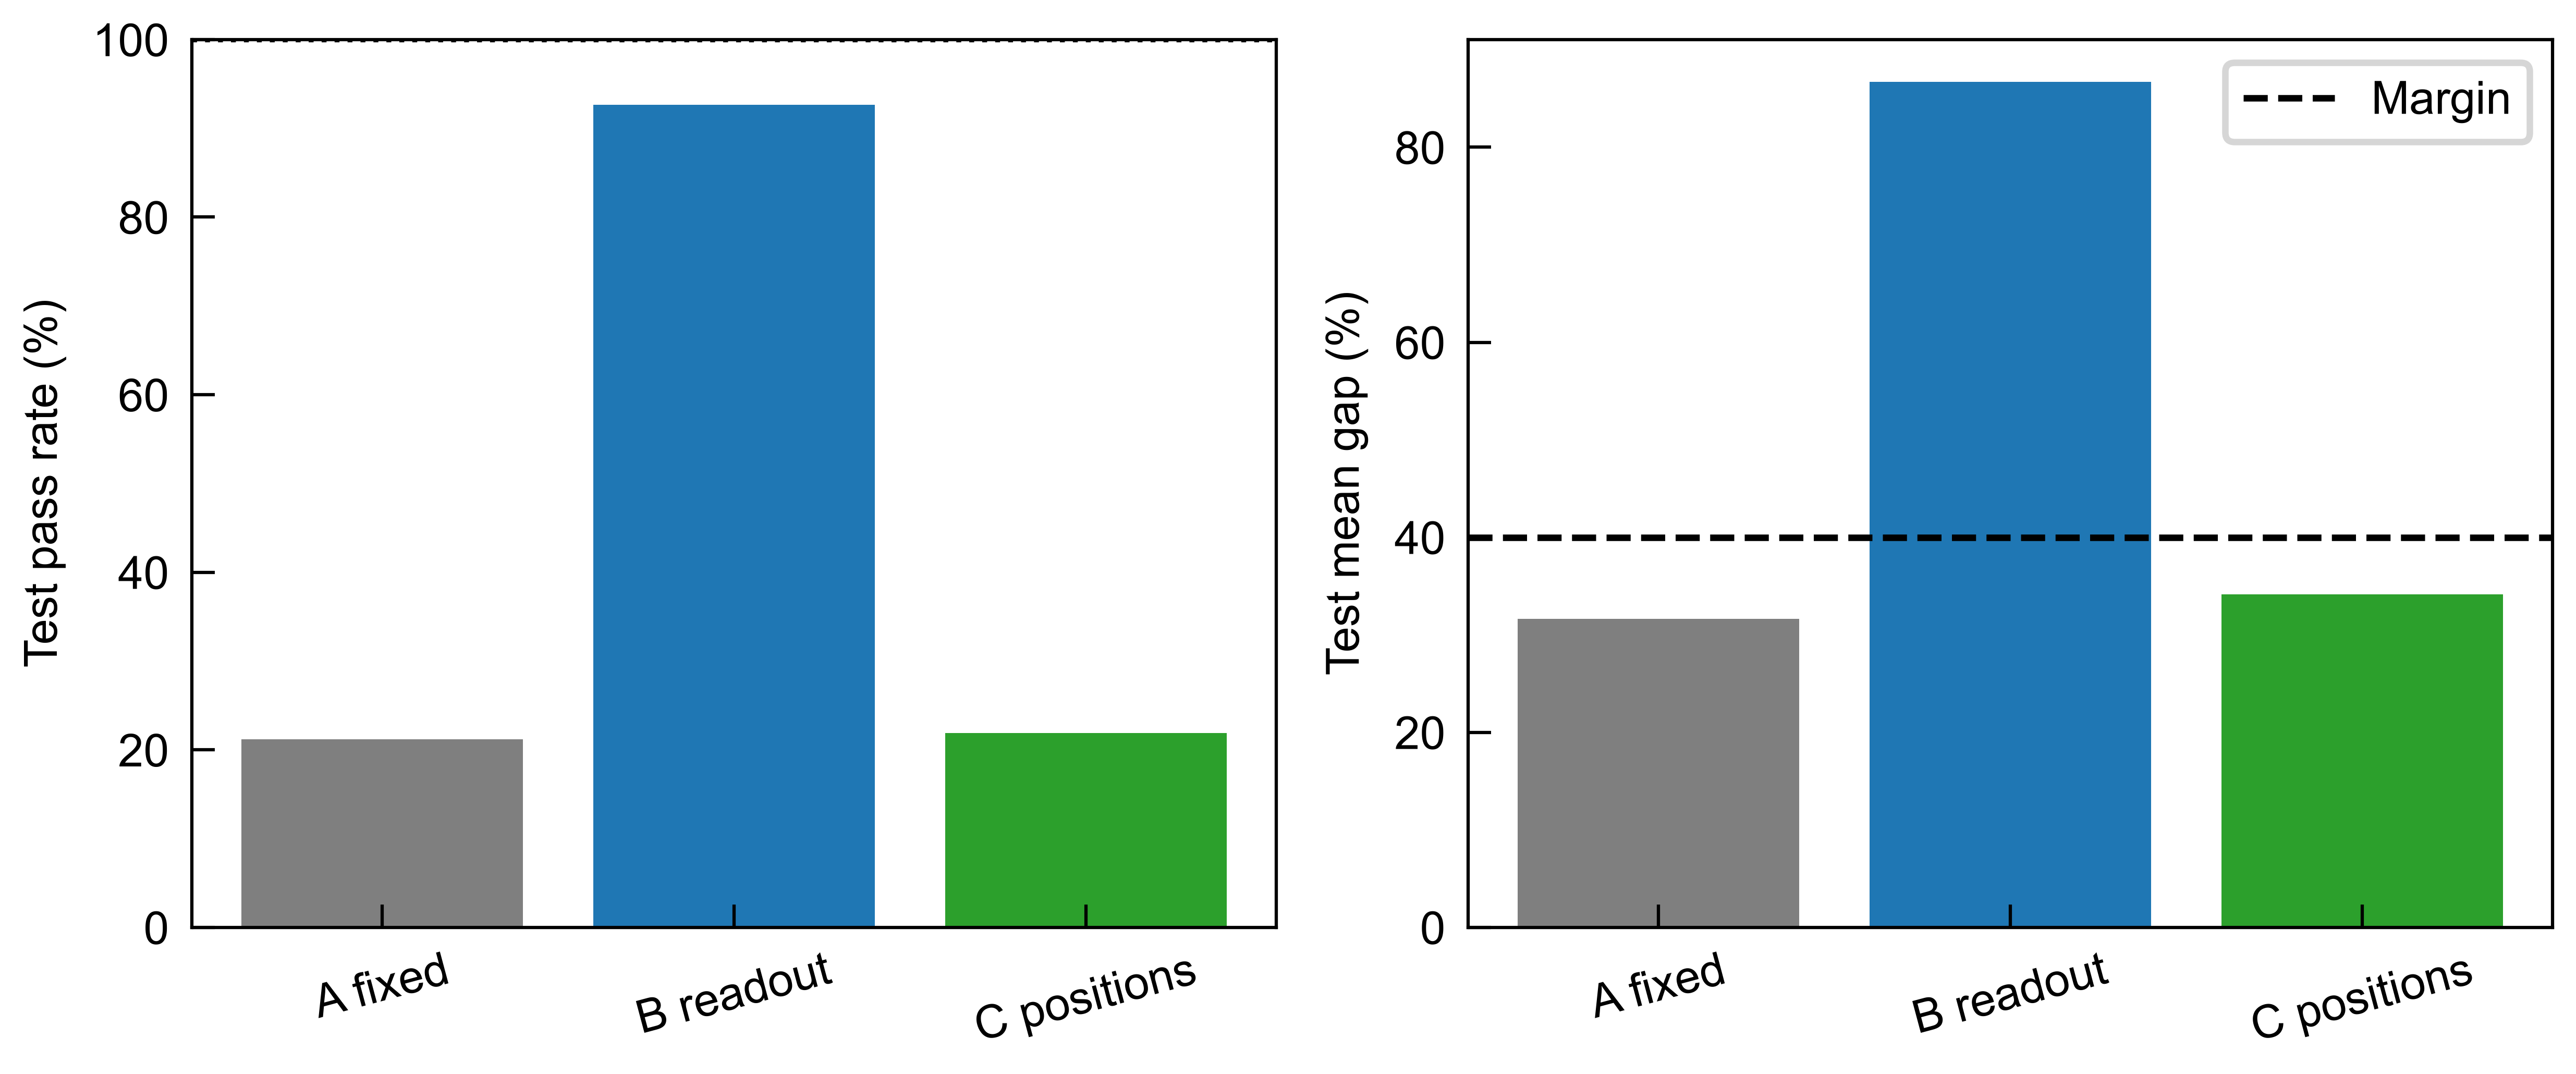

In [15]:
summary = {
    "A fixed": gap_test_A,
    "B readout": gap_test_B,
    "C positions": gap_test_C,
}

print(f"{'Variant':<14} {'mean gap':>9} {'pass rate':>10}")
for name, gap in summary.items():
    print(f"{name:<14} {gap.mean().item():>8.3f} {100 * (gap > relative_margin).float().mean().item():>9.1f}%")

fig, ax = plt.subplots(1, 2, figsize=(5.6, 2.4), tight_layout=True)
names = list(summary.keys())
colors = ["tab:gray", "tab:blue", "tab:green"]
ax[0].bar(names, [100 * (g > relative_margin).float().mean().item() for g in summary.values()], color=colors)
ax[0].set(ylabel="Test pass rate (%)", ylim=(0, 100))
ax[0].axhline(100, color="k", ls=":", lw=0.75)
ax[1].bar(names, [100 * g.mean().item() for g in summary.values()], color=colors)
ax[1].axhline(relative_margin_pct, color="k", ls="--", lw=1, label="Margin")
ax[1].set(ylabel="Test mean gap (%)")
ax[1].legend(fontsize=7)
for axis in ax:
    axis.tick_params(axis="x", labelrotation=15)

shared_config = {
    "N_det": N_det,
    "det_width": det_width,
    "det_centers_init": det_centers,
    "class_names": class_names,
    "train_indices": train_idx,
    "val_indices": val_idx,
    "test_indices": test_idx,
    "dataset_files": {key: str(value) for key, value in DATASET_FILES.items()},
    "relative_margin": relative_margin,
}

torch.save(
    {
        "model_state_dict": res_B["state_opt"],
        "initial_state_dict": res_B["state_init"],
        "best_val_loss": res_B["best_val_loss"],
        "best_epoch": res_B["best_epoch"],
        "power_floor": res_B["power_floor"],
        "history": res_B["history"],
        **shared_config,
    },
    "no_ms_digital_readout_trained.pt",
)

torch.save(
    {
        "model_state_dict": res_C["state_opt"],
        "initial_state_dict": res_C["state_init"],
        "best_val_loss": res_C["best_val_loss"],
        "best_epoch": res_C["best_epoch"],
        "power_floor": res_C["power_floor"],
        "history": res_C["history"],
        "det_centers_trained": centers_opt,
        **shared_config,
    },
    "no_ms_trainable_detectors_trained.pt",
)

print("Saved checkpoints: no_ms_digital_readout_trained.pt, no_ms_trainable_detectors_trained.pt")

## 12. Threshold-Free Detection Evaluation (ROC / AUC)

The 40% margin is one operating point of many. Here each variant is evaluated as a detector over *all* thresholds:

- **Negatives**: simulated intact measurements - the intact field plus complex Gaussian measurement noise (`intact_noise_rel` relative RMS amplitude).
- **Positives**: the defect test fields with the same measurement noise added.
- **Scores**: the whole-vector relative L2 gap, and a per-detector max deviation ("Linf") gap `max_i |det_i - det0_i| / det0_i`, which a single anomalous detector can trigger - irrelevant detectors cannot dilute it.

Reported: ROC curves, AUC (the probability that a random defect scores above a random intact measurement; 0.5 = blind, 1.0 = perfect), and the detection rate at a 1% false-alarm rate - the noise-calibrated analog of the pass rate. Comparing the L2 and Linf columns tests whether the fixed array is truly blind to a defect class or only mis-measured by the whole-vector metric.

`intact_noise_rel` is a modeling choice - replace it with the measured noise level of the real readout when available.

Variant        metric       AUC  TPR@1%FPR  noise max  defect min   per-class AUC
A fixed        L2 gap     0.997      95.4%      0.147       0.085   crack 0.998, dent 0.999, wear 0.994
A fixed        Linf gap   0.983      81.1%      0.487       0.165   crack 0.989, dent 0.991, wear 0.970
B readout      L2 gap     0.999      97.9%      0.445       0.143   crack 0.999, dent 1.000, wear 0.997
B readout      Linf gap   0.998      97.3%      0.781       0.295   crack 1.000, dent 0.999, wear 0.996
C positions    L2 gap     0.999      98.4%      0.155       0.074   crack 1.000, dent 1.000, wear 0.996
C positions    Linf gap   0.992      88.7%      0.400       0.148   crack 0.996, dent 0.996, wear 0.985


Text(0, 0.5, 'True positive rate')

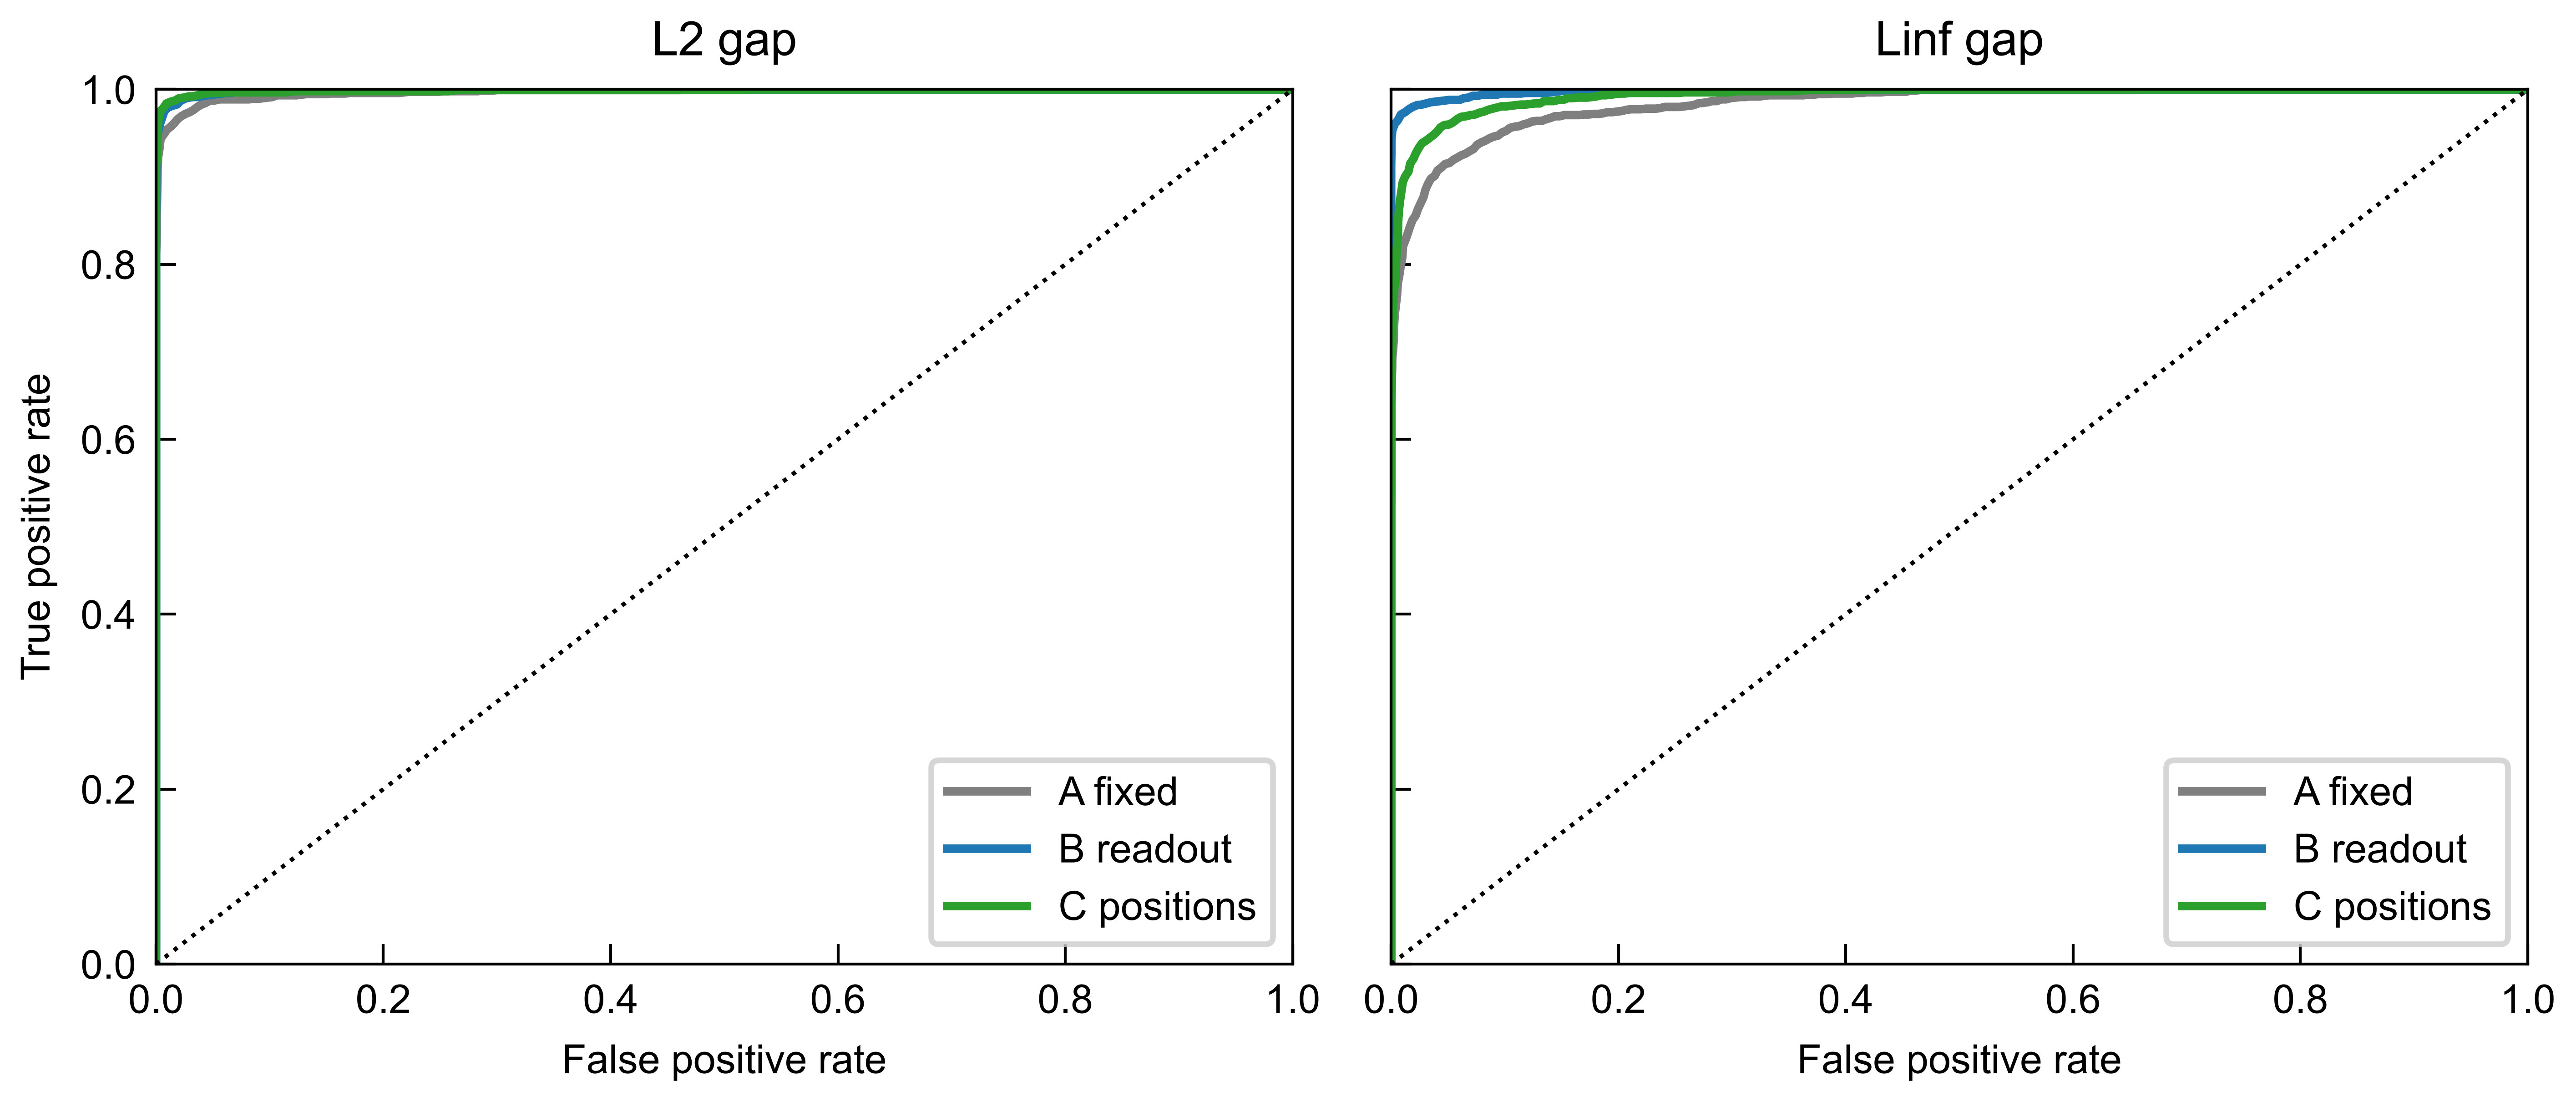

In [18]:
# Simulated measurement noise (relative to the unit-RMS field amplitude).
intact_noise_rel = 0.2
N_neg = 5000

gen = torch.Generator().manual_seed(1)


def complex_noise(n: int, g: torch.Generator) -> torch.Tensor:
    real = torch.randn(n, resol, generator=g)
    imag = torch.randn(n, resol, generator=g)
    return ((real + 1j * imag) / np.sqrt(2)).to(torch.complex64)


fields_neg = psi_ms0.reshape(1, -1) + intact_noise_rel * complex_noise(N_neg, gen)
fields_pos = test_ds.field + intact_noise_rel * complex_noise(len(test_ds), gen)


def linf_gap(det: torch.Tensor, det0: torch.Tensor, eps: float = 1e-12) -> torch.Tensor:
    # Largest single-detector relative deviation from the intact barcode.
    return ((det - det0).abs() / det0.clamp_min(eps)).max(dim=1).values


def auc_score(pos: torch.Tensor, neg: torch.Tensor) -> float:
    # Probability that a random positive outscores a random negative (ties count half).
    cmp = (pos.reshape(-1, 1) > neg.reshape(1, -1)).float()
    cmp += 0.5 * (pos.reshape(-1, 1) == neg.reshape(1, -1)).float()
    return cmp.mean().item()


def tpr_at_fpr(pos: torch.Tensor, neg: torch.Tensor, fpr: float = 0.01) -> float:
    # Detection rate when the threshold is set for the given false-alarm rate.
    threshold = torch.quantile(neg, 1.0 - fpr)
    return (pos > threshold).float().mean().item()


def roc_points(pos: torch.Tensor, neg: torch.Tensor, n: int = 300) -> tuple[torch.Tensor, torch.Tensor]:
    thresholds = torch.quantile(torch.cat([pos, neg]), torch.linspace(0, 1, n))
    fpr = torch.tensor([(neg > t).float().mean() for t in thresholds])
    tpr = torch.tensor([(pos > t).float().mean() for t in thresholds])
    return fpr, tpr


variant_models = {
    "A fixed": baseline,
    "B readout": readout,
    "C positions": softdet,
}
score_fns = {"L2 gap": relative_l2_gap, "Linf gap": linf_gap}

roc_results = {}
print(f"{'Variant':<14} {'metric':<9} {'AUC':>6} {'TPR@1%FPR':>10} {'noise max':>10} {'defect min':>11}   per-class AUC")
for name, model in variant_models.items():
    det_pos, det0_ref = evaluate_detectors(model, fields_pos)
    det_neg, _ = evaluate_detectors(model, fields_neg)
    for metric_name, score_fn in score_fns.items():
        s_pos = score_fn(det_pos, det0_ref)
        s_neg = score_fn(det_neg, det0_ref)
        auc = auc_score(s_pos, s_neg)
        tpr = tpr_at_fpr(s_pos, s_neg)
        class_aucs = ", ".join(
            f"{class_name} {auc_score(s_pos[target_test == class_id], s_neg):.3f}"
            for class_id, class_name in enumerate(class_names)
        )
        roc_results[(name, metric_name)] = (s_pos, s_neg)
        print(f"{name:<14} {metric_name:<9} {auc:>6.3f} {100 * tpr:>9.1f}% {s_neg.max():>10.3f} {s_pos.min():>11.3f}   {class_aucs}")

fig, ax = plt.subplots(1, 2, figsize=(6.4, 2.8), tight_layout=True, sharey=True)
variant_colors = {"A fixed": "tab:gray", "B readout": "tab:blue", "C positions": "tab:green"}
for (name, metric_name), (s_pos, s_neg) in roc_results.items():
    axis = ax[0] if metric_name == "L2 gap" else ax[1]
    fpr, tpr = roc_points(s_pos, s_neg)
    axis.plot(fpr, tpr, color=variant_colors[name], label=name)
for axis, title in zip(ax, score_fns.keys()):
    axis.plot([0, 1], [0, 1], "k:", lw=0.75)
    axis.set(xlabel="False positive rate", title=title, xlim=(0, 1), ylim=(0, 1))
    axis.legend(fontsize=7, loc="lower right")
ax[0].set_ylabel("True positive rate")